In [1]:
import pandas as pd
df = pd.read_csv('./data/cleaned_speakers_data.csv')
df.head(5)

,user_id,session_id,sign_in,name,demographic_age,demographic_age_group,demographic_gender,email,location,country,...,pages_visited,conversion_flag,conversion_type,traffic_source,product_purchased,revenue_$,payment_type,card_type,coupon_applied,bounce_flag
0,U10477,S000001,Email,Victor Navarro-Noël,31,Adult,Female,victornavarronoël251@hotmail.com,Rome,Italy,...,7,0,NCT,Organic,NPP,0.0,NPT,NCAT,ND,1
1,U01536,S000002,Email,王秀云,39,Adult,Female,王秀云617@gmail.com,Madrid,Spain,...,5,0,NCT,Social,NPP,0.0,NPT,NCAT,ND,0
2,U00107,S000003,Guest,Ucchal Sabharwal,68,Old,Male,Not Provided,Manchester,UK,...,7,0,NCT,Organic,NPP,0.0,NPT,NCAT,ND,0
3,U13886,S000004,Email,Virginie Schmitt,72,Old,Female,virginieschmitt827@gmail.com,Sydney,Australia,...,10,0,NCT,Social,NPP,0.0,NPT,NCAT,ND,0
4,U05926,S000005,Email,Cynthia Drake,51,Adult,No Answer,cynthiadrake47@hotmail.com,Mumbai,India,...,6,0,NCT,Organic,NPP,0.0,NPT,NCAT,ND,0


In [2]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                30000 non-null  object 
 1   session_id             30000 non-null  object 
 2   sign_in                30000 non-null  object 
 3   name                   30000 non-null  object 
 4   demographic_age        30000 non-null  int64  
 5   demographic_age_group  30000 non-null  object 
 6   demographic_gender     30000 non-null  object 
 7   email                  30000 non-null  object 
 8   location               30000 non-null  object 
 9   country                30000 non-null  object 
 10  device_type            30000 non-null  object 
 11  timestamp              30000 non-null  object 
 12  variant_group          30000 non-null  object 
 13  time_spent             30000 non-null  float64
 14  pages_visited          30000 non-null  int64  
 15  co

,demographic_age,time_spent,pages_visited,conversion_flag,revenue_$,bounce_flag
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,46.905533,10.524185,5.501467,0.151167,26.208553,0.189067
std,19.405500,5.481363,2.874208,0.358217,137.294872,0.391568
min,14.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,5.780000,3.000000,0.000000,0.000000,0.000000
50%,47.000000,10.580000,5.000000,0.000000,0.000000,0.000000
75%,64.000000,15.270000,8.000000,0.000000,0.000000,0.000000
max,80.000000,20.000000,10.000000,1.000000,2499.000000,1.000000


In [3]:
df.duplicated().sum()

np.int64(0)

In [11]:
num_columns = df.select_dtypes(include='number').columns
cat_columns = df.select_dtypes(include=['object','category']).columns
exclude_columns = ['user_id','session_id','name','email','location','country','timestamp','product_purchased']
cat_columns = cat_columns.drop(exclude_columns)
key_columns = ['conversion_flag','revenue_$']

In [12]:
# categorical columns: check distinct values
cat_summary = df[cat_columns].nunique().reset_index()
cat_summary.columns = ['column_name','distinct_values']
cat_summary.sort_values('distinct_values',ascending=False)

,column_name,distinct_values
6,traffic_source,4
8,card_type,4
1,demographic_age_group,3
2,demographic_gender,3
3,device_type,3
4,variant_group,3
5,conversion_type,3
7,payment_type,3
9,coupon_applied,3
0,sign_in,2


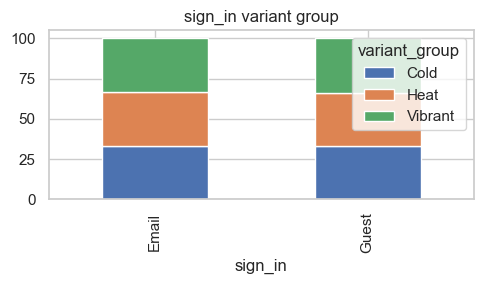

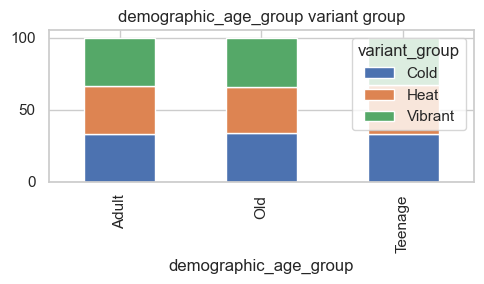

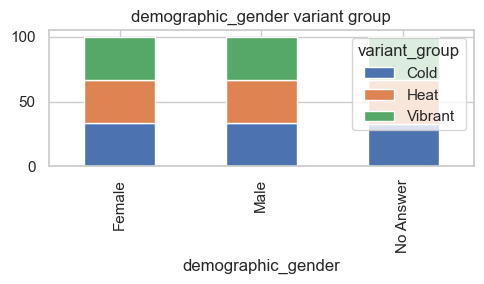

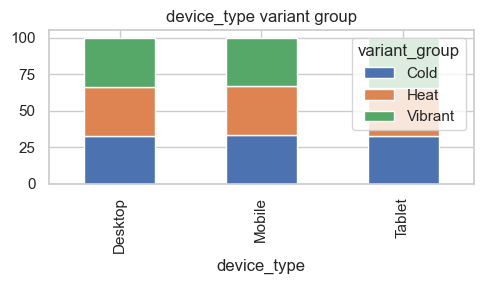

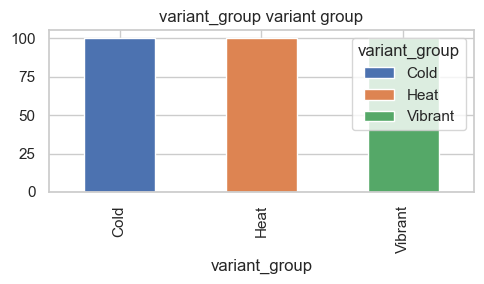

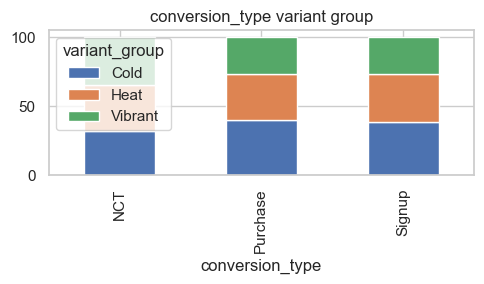

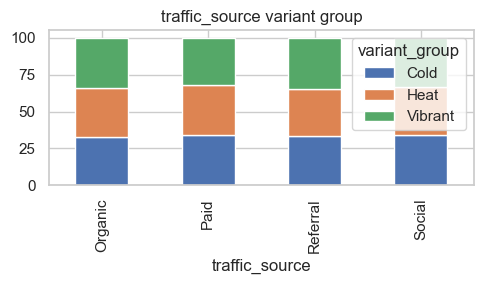

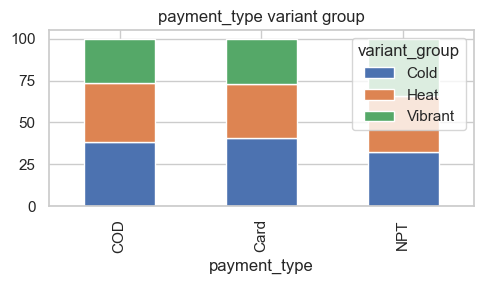

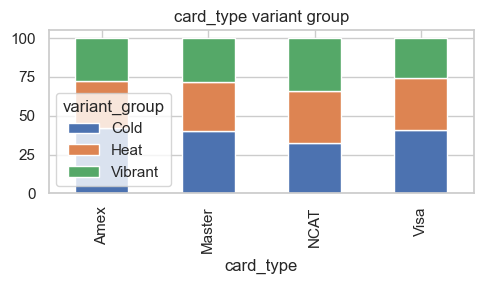

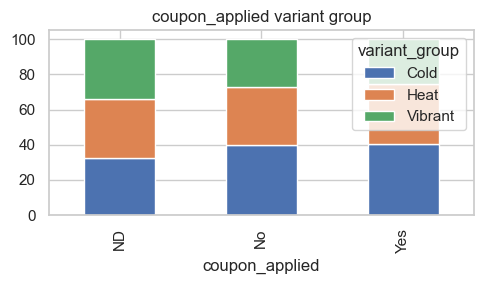

In [24]:
# visualize categorical data balance variant_group
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style='whitegrid')
for col in cat_columns:
    group_df = pd.crosstab(df[col],df['variant_group'],normalize='index')*100
    group_df.plot(kind='bar',stacked=True,figsize=(5,3))
    plt.title(f'{col} variant group')
    plt.tight_layout()
    plt.show()

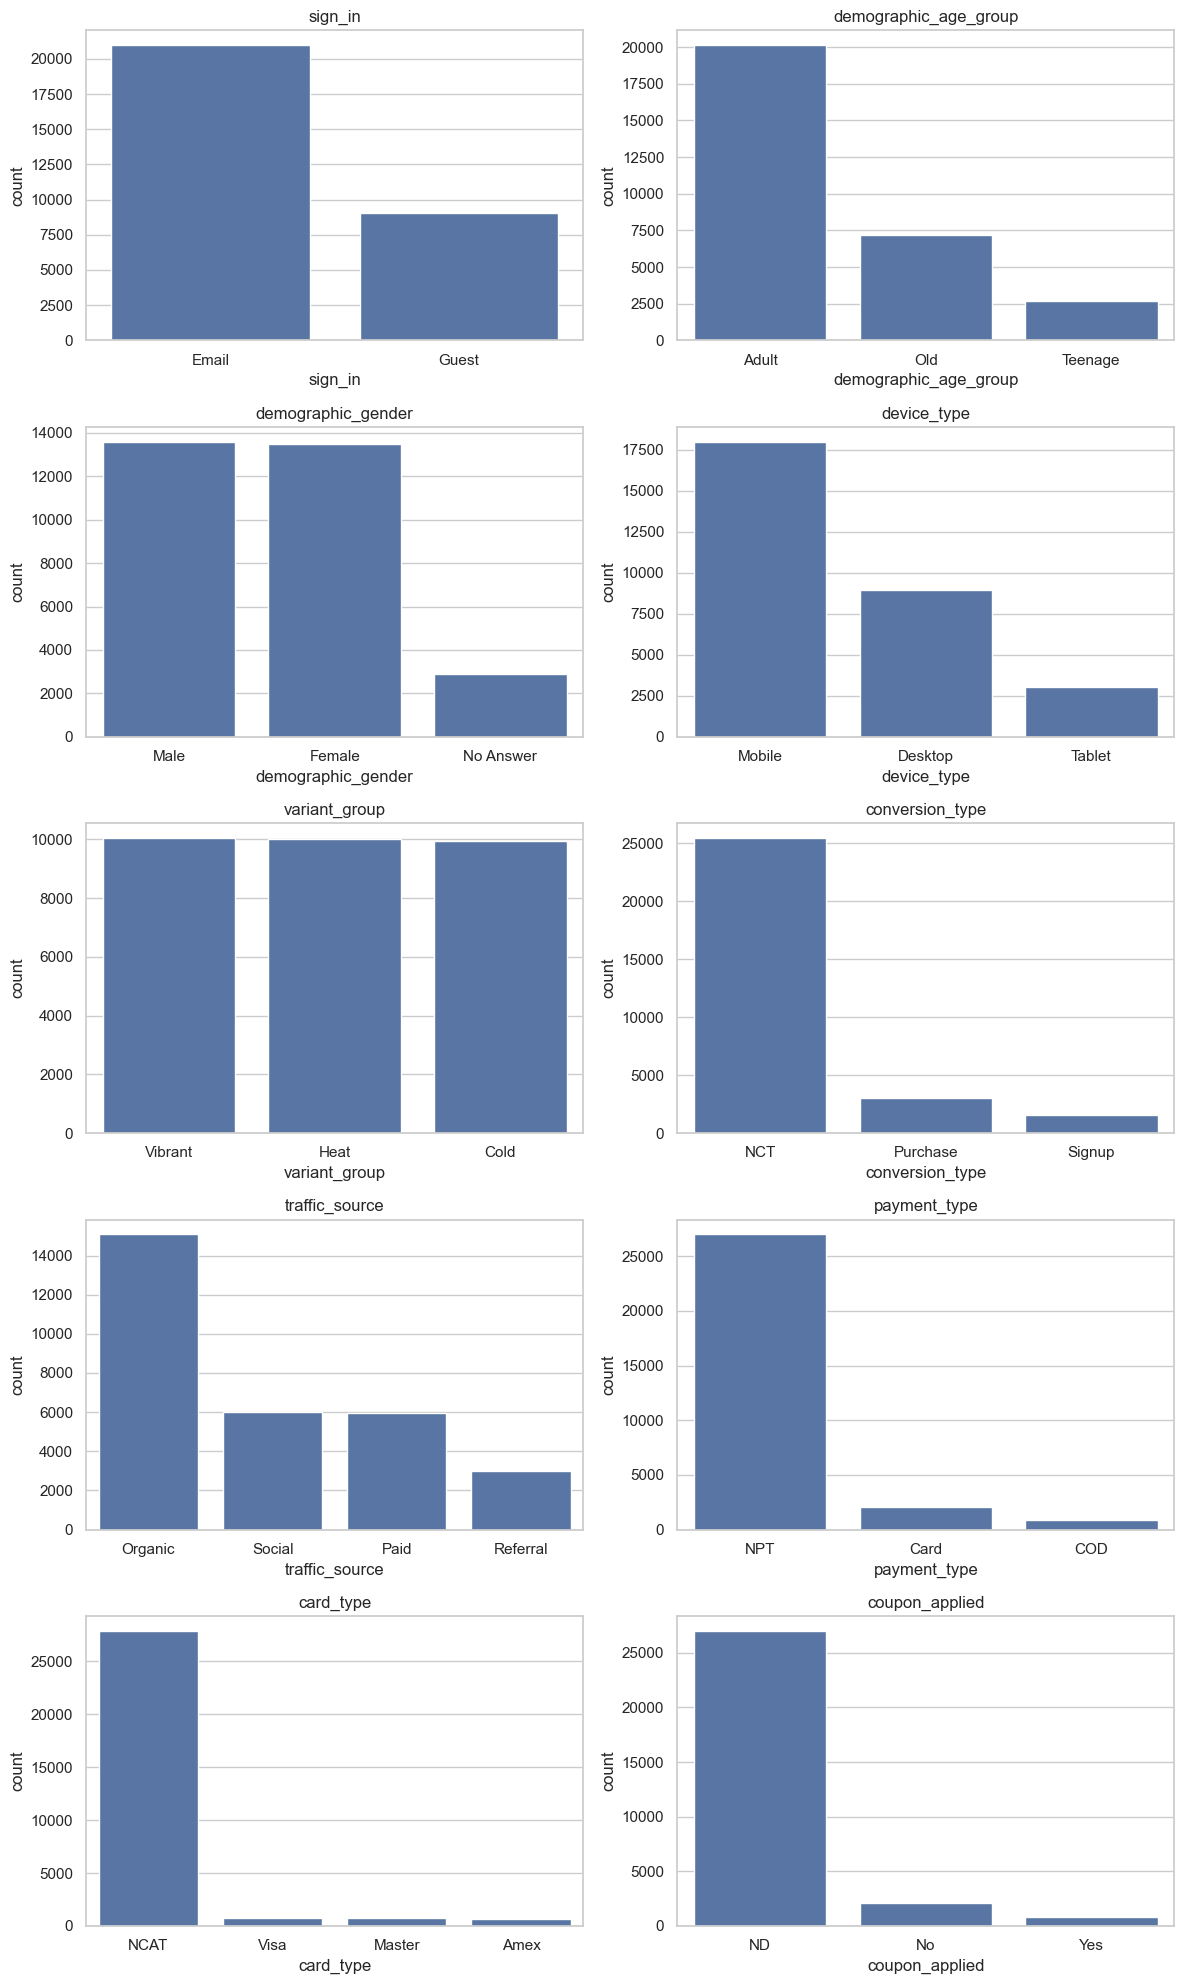

In [33]:
# pie chart to check cat columns balance
import math
sns.set_theme(style='whitegrid')
n_cols = 2
n_rows = math.ceil(len(cat_columns)/n_cols)
fig, axes = plt.subplots(n_rows,n_cols,figsize=(12,4*n_rows))
axes = axes.flatten()
for i,col in enumerate(cat_columns):
    sns.countplot(data=df,x=col,order=df[col].value_counts().index,ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

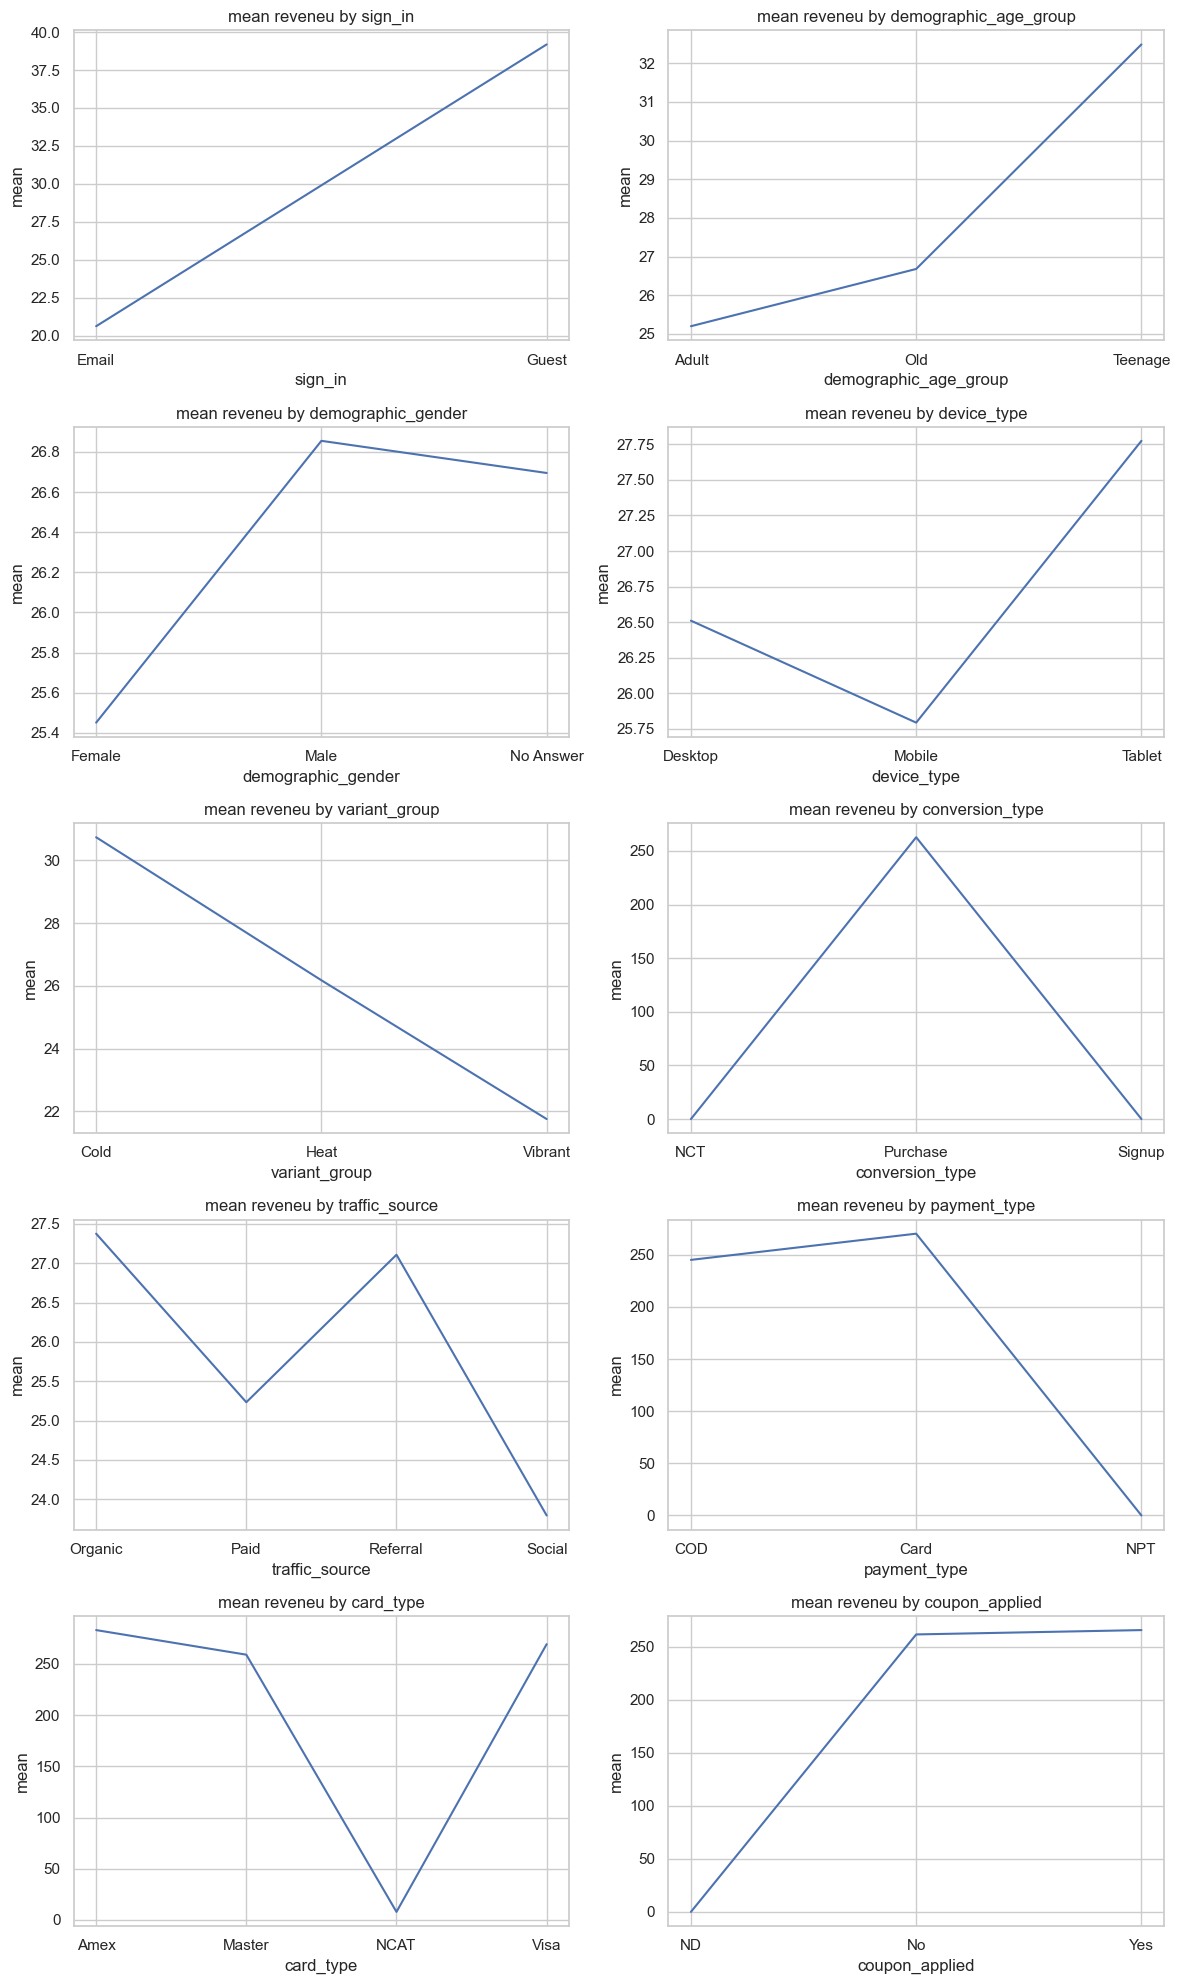

In [40]:
# check mean values of target columns among categorical data
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(n_rows,n_cols,figsize=(12,4*n_rows))
axes = axes.flatten()
for i,col in enumerate(cat_columns):
    group_df = df.groupby(col)['revenue_$'].mean().reset_index(name='mean')
    sns.lineplot(group_df,x=col,y='mean',ax=axes[i])
    axes[i].set_title(f'mean reveneu by {col}')
plt.tight_layout()
plt.show()

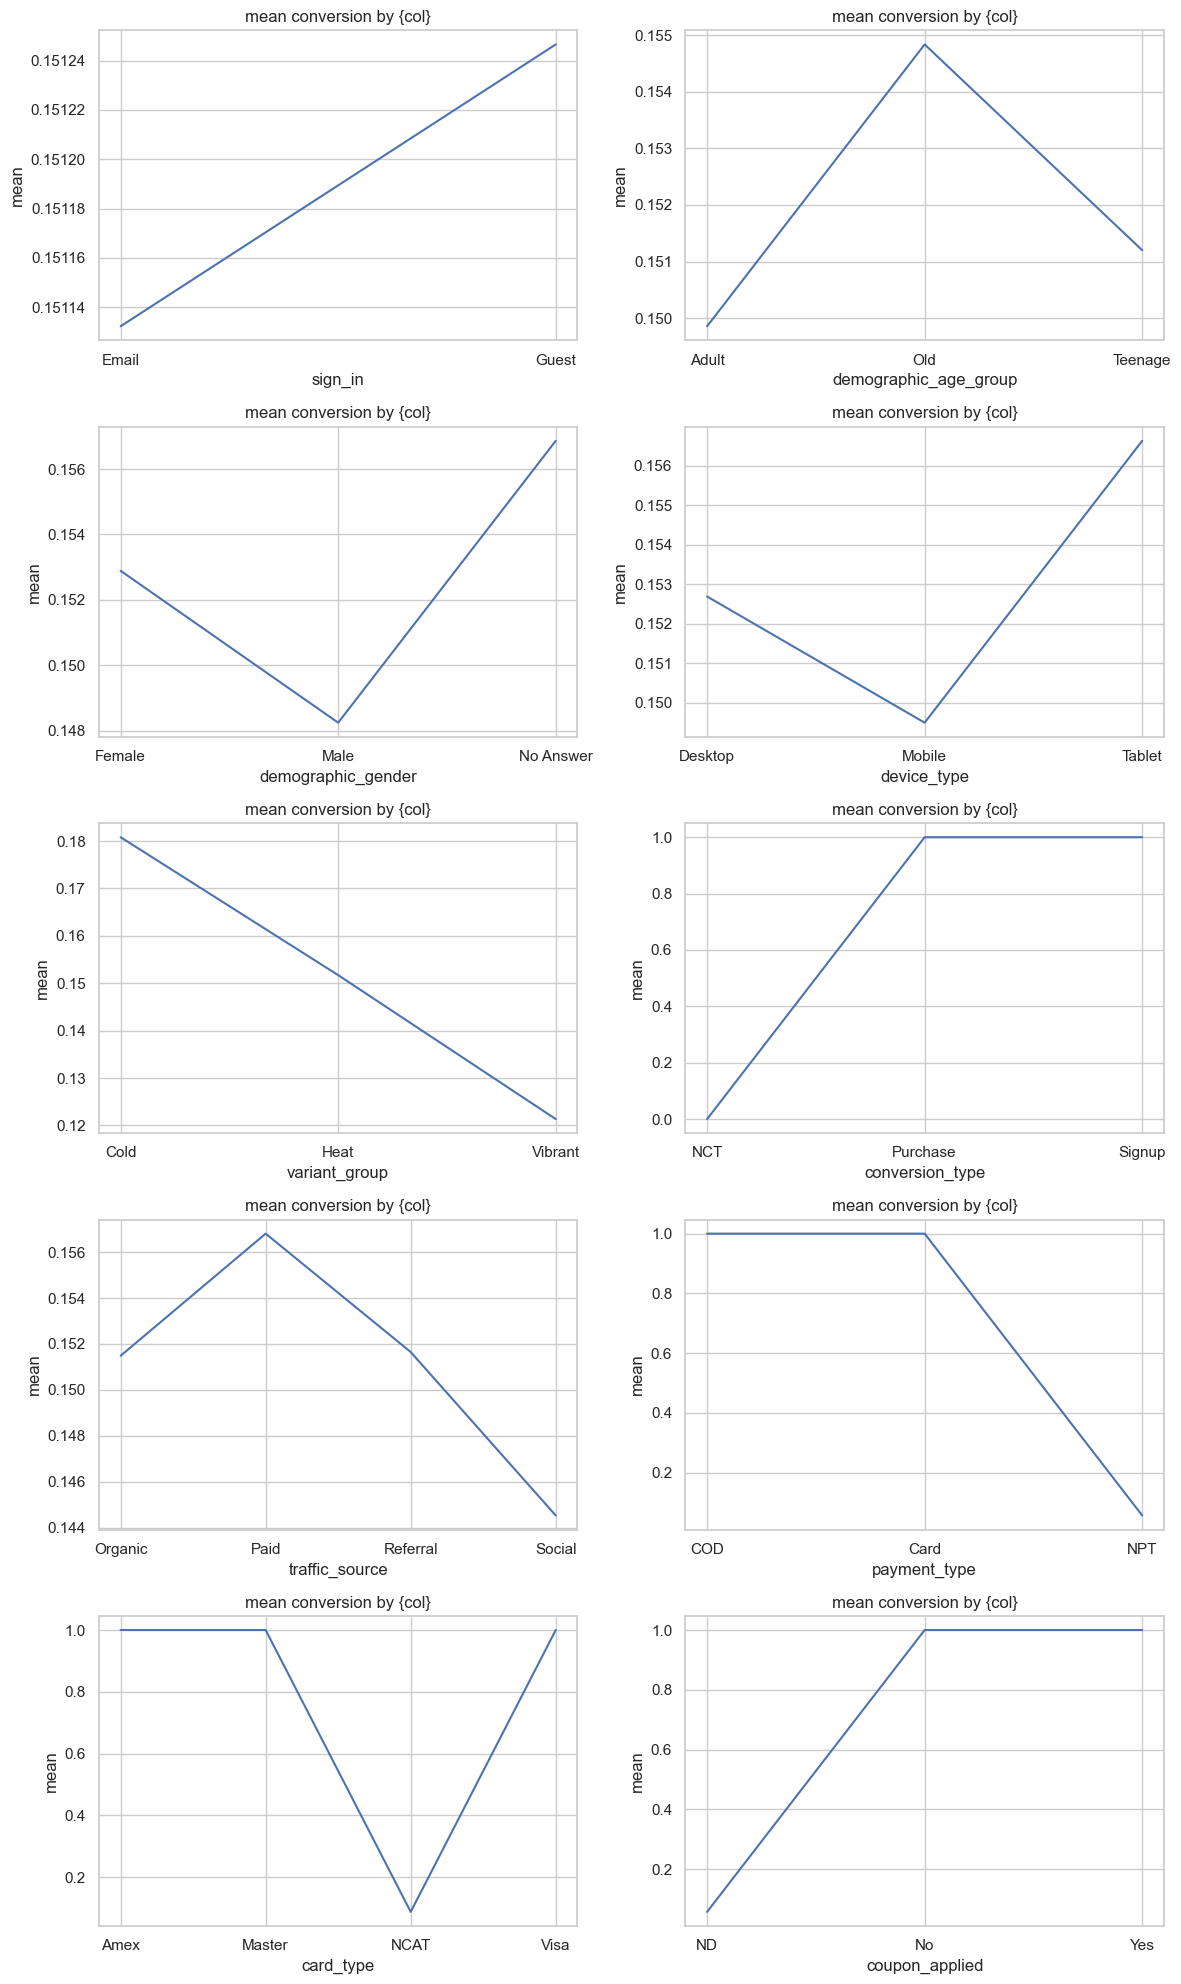

In [ ]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(n_rows,n_cols,figsize=(12,4*n_rows))
axes = axes.flatten()
for i,col in enumerate(cat_columns):
    group_df = df.groupby(col)['conversion_flag'].mean().reset_index(name='mean')
    sns.lineplot(group_df,x=group_df[col],y=group_df['mean'],ax=axes[i])
    axes[i].set_title(f'mean conversion by {col}')
plt.tight_layout()
plt.show()

In [ ]:
# ['coupon_applied','card_type','payment_type','conversion_type'] <- 'revenue_$'
# ['coupon_applied','card_type','payment_type','conversion_type'] <- 'conversion_flag'
cat_columns = cat_columns.drop(['coupon_applied','card_type','payment_type','conversion_type'])

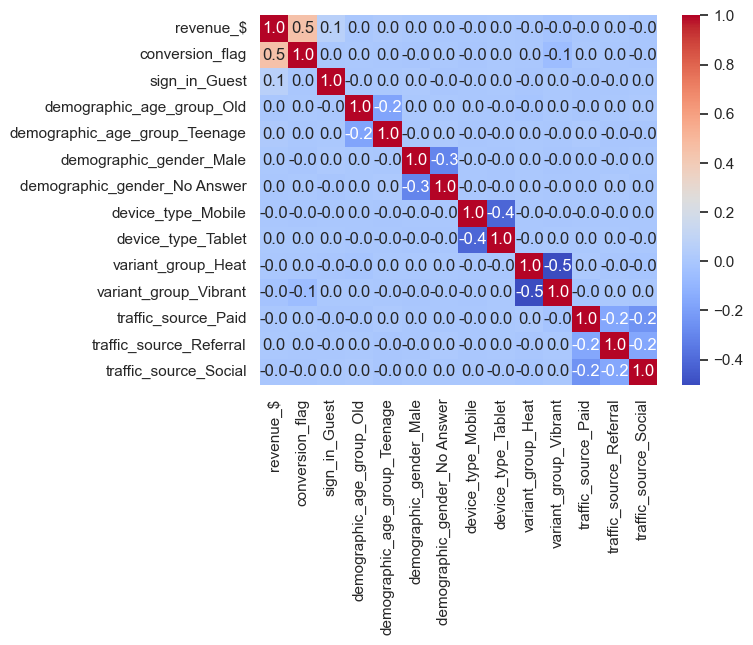

In [60]:
cat_encoded = pd.get_dummies(df[cat_columns.tolist() + ['revenue_$','conversion_flag']],columns=cat_columns,drop_first=True)
corr_df = cat_encoded.corr()
sns.heatmap(corr_df,cmap='coolwarm',annot=True,fmt='.1f')
plt.show()

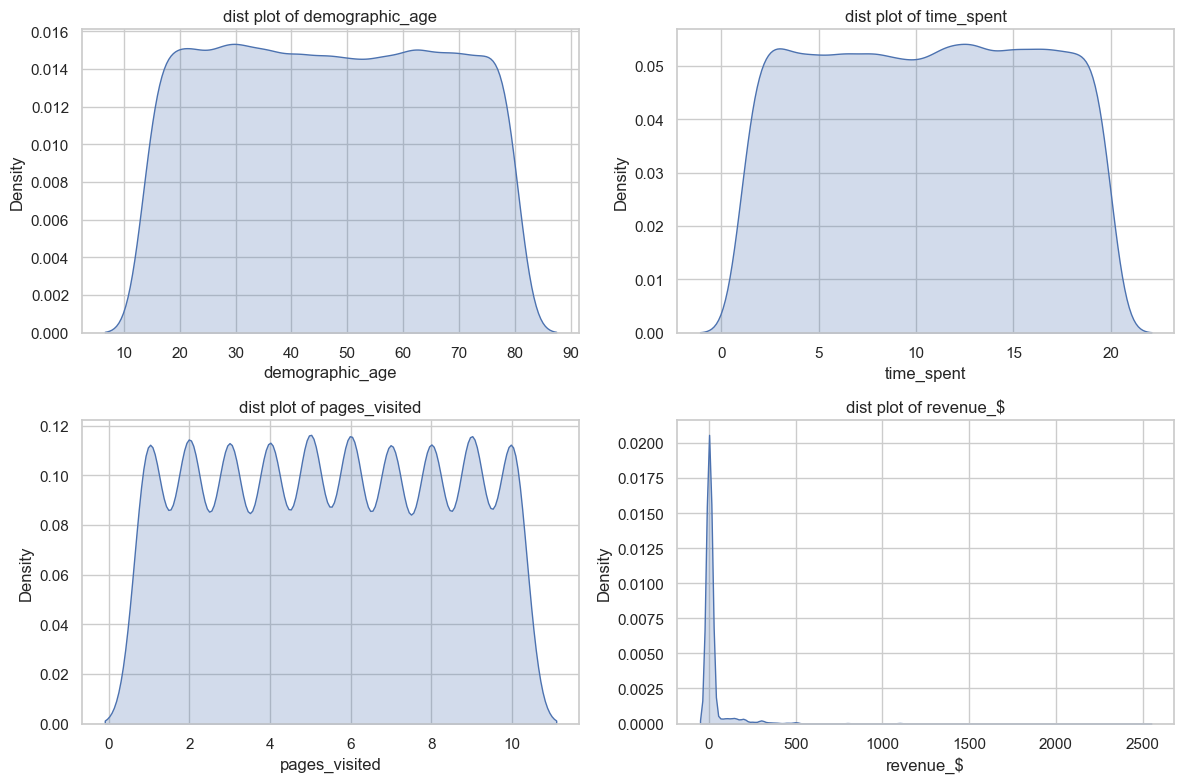

In [48]:
# number columns: distribution, correlation
exclude_columns = ['conversion_flag','bounce_flag']
num_columns = num_columns.drop(exclude_columns)
n_cols = 2
n_rows = math.ceil(len(num_columns)/n_cols)
fig, axes = plt.subplots(n_rows,n_cols,figsize=(12,4*n_rows))
axes = axes.flatten()
for i,col in enumerate(num_columns):
    sns.kdeplot(data=df,x=col,fill=True,ax=axes[i])
    axes[i].set_title(f'dist plot of {col}')
plt.tight_layout()
plt.show()

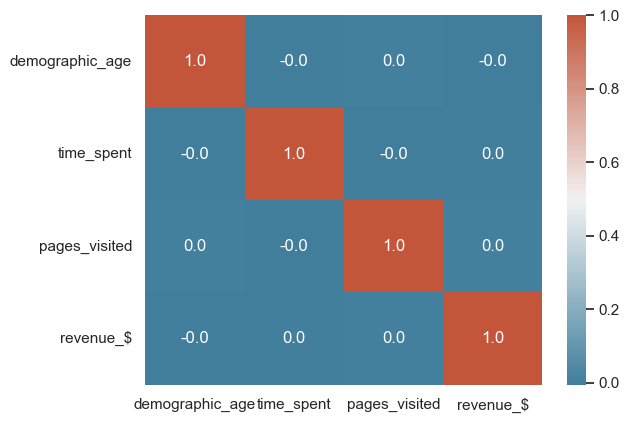

In [51]:
corr_df = df[num_columns].corr()
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr_df,annot=True,fmt='.1f',cmap=cmap)
plt.show()

In [62]:
# statistical test for confounding:
from scipy.stats import ttest_ind, kruskal,chi2_contingency
for col in cat_columns:
    table = pd.crosstab(df[col],df['variant_group'])
    chi2,p,_, _= chi2_contingency(table)
    print(f'{col} and {p}')
for col in num_columns:
    group_df = [group[col].values for name,group in df.groupby('variant_group')]
    stat,p_value = kruskal(*group_df)
    print(f'{col}: h stats: {stat} & p: {p_value}')

sign_in and 0.6414718699544895
demographic_age_group and 0.4265297195292017
demographic_gender and 0.7967476600744705
device_type and 0.8506042414677579
variant_group and 0.0
traffic_source and 0.011833346609451458
demographic_age: h stats: 5.527621192514464 & p: 0.06305104791950458
time_spent: h stats: 1.007736542270348 & p: 0.6041889667407314
pages_visited: h stats: 0.179173593896475 & p: 0.9143089024576561
revenue_$: h stats: 93.41802905720189 & p: 5.182421532082818e-21


In [63]:
pd.crosstab(df['variant_group'],df['traffic_source'],normalize='index')*100

traffic_source,Organic,Paid,Referral,Social
variant_group,,,,
Cold,49.274778,20.265915,9.981869,20.477438
Heat,50.608418,20.436864,9.555157,19.399561
Vibrant,50.945650,18.803504,10.203066,20.047780


In [ ]:
# VIF to check multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_df = pd.DataFrame()
vif_df['feature'] = df[num_columns].columns
vif_df['VIF'] = [variance_inflation_factor(df[num_columns].values,i) for i in range(df[num_columns].shape[1])]
vif_df.sort_values('VIF',ascending=False)
# VIF <5: good, 5-10: moderate concern, >10: high multicollinearity

,feature,VIF
0,demographic_age,4.025724
2,pages_visited,3.470654
1,time_spent,3.453941
3,revenue_$,1.033944


## Experiment test
### Null hypothesis: variant groups have no impact on revenue and conversion

In [77]:
# test conversion
table = pd.crosstab(df['variant_group'],df['conversion_flag'])
chi2,p,_,_=chi2_contingency(table)
print(p)
from statsmodels.stats.proportion import proportions_ztest
from itertools import combinations
alpha = 0.05/3
summary = df.groupby('variant_group')['conversion_flag'].agg(['sum','count'])
groups = summary.index.tolist()
for g1,g2 in combinations(groups,2):
    count = [summary.loc[g1,'sum'],summary.loc[g2,'sum']]
    nobs = [summary.loc[g1,'count'],summary.loc[g2,'count']]
    z_stat, p_value = proportions_ztest(count,nobs)
    print(f'{g1} vs {g2}: p={p_value:.5f}')

1.309569103163871e-30
Cold vs Heat: p=0.00000
Cold vs Vibrant: p=0.00000
Heat vs Vibrant: p=0.00000


<Axes: xlabel='variant_group', ylabel='revenue_$'>

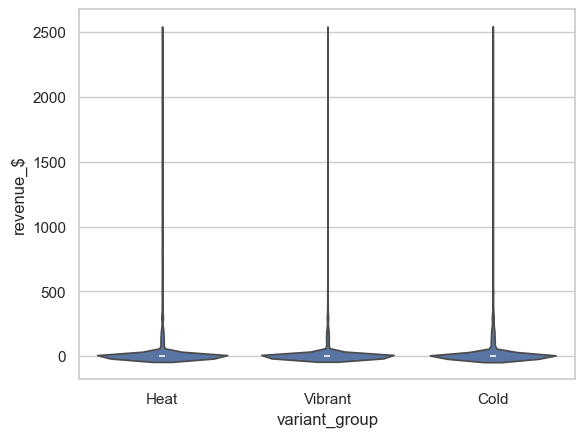

In [73]:
# test revenue
sns.violinplot(data=df,x='variant_group',y='revenue_$')

In [75]:
# not normal use kruskal test for 2+ groups
group = [g['revenue_$'] for _,g in df.groupby('variant_group')]
stat, p = kruskal(*group)
print(p)
import scikit_posthocs as sp
sp.posthoc_dunn(df,val_col='revenue_$',group_col='variant_group',p_adjust='bonferroni')

5.182421532082818e-21


,Cold,Heat,Vibrant
Cold,1.000000e+00,3.036426e-07,1.478069e-21
Heat,3.036426e-07,1.000000e+00,4.407537e-05
Vibrant,1.478069e-21,4.407537e-05,1.000000e+00


In [81]:
# bootstrap revenue for CI, mean test
import numpy as np
from scipy.stats import norm
for g1,g2 in combinations(groups,2):
    r1 = df[df['variant_group']==g1]['revenue_$']
    r2 = df[df['variant_group']==g2]['revenue_$']
    obs_difs = r1.mean() - r2.mean()
    boot_diffs = []
    for _ in range(5000):
        s1 = r1.sample(n=len(r1),replace=True)
        s2 = r2.sample(n=len(r2),replace=True)
        boot_diffs.append(s1.mean()-s2.mean())
    ci = np.quantile(boot_diffs,[0.025,0.975])
    mean_diff = np.mean(boot_diffs)
    se = np.std(boot_diffs, ddof=1)
    z = mean_diff/se
    p = 2 * (1-norm.cdf(abs(z)))
    print(f'{g1} - {g2}: CI: {ci} and P value: {p}')

Cold - Heat: CI: [0.66373359 8.57576355] and P value: 0.02078257221849933
Cold - Vibrant: CI: [ 5.19836002 12.84588634] and P value: 4.320082733322295e-06
Heat - Vibrant: CI: [0.68815434 8.27775811] and P value: 0.02138074156150549


In [84]:
# revenue among converted
for g1,g2 in combinations(groups,2):
    r1 = df[(df['variant_group']==g1)&(df['conversion_flag']==1)]['revenue_$']
    r2 = df[(df['variant_group']==g2)&(df['conversion_flag']==1)]['revenue_$']
    obs_difs = r1.mean() - r2.mean()
    boot_diffs = []
    for _ in range(5000):
        s1 = r1.sample(n=len(r1),replace=True)
        s2 = r2.sample(n=len(r2),replace=True)
        boot_diffs.append(s1.mean()-s2.mean())
    ci = np.quantile(boot_diffs,[0.025,0.975])
    mean_diff = np.mean(boot_diffs)
    se = np.std(boot_diffs, ddof=1)
    z = mean_diff/se
    p = 2 * (1-norm.cdf(abs(z)))
    print(f'{g1} - {g2}: CI: {ci} and P value: {p}')

Cold - Heat: CI: [-24.14276591  18.41642747] and P value: 0.7937582399348042
Cold - Vibrant: CI: [-33.17259997  13.73397743] and P value: 0.4288588761691008
Heat - Vibrant: CI: [-31.68871984  17.74463541] and P value: 0.5901673761658282


## check effect size

In [83]:
for g1,g2 in combinations(groups,2):
    # revenue
    x1 = df[df['variant_group']==g1]['revenue_$']
    x2 = df[df['variant_group']==g2]['revenue_$']
    mean_diff = x1.mean() - x2.mean()
    pooled_std = np.sqrt((x1.var(ddof=1)+x2.var(ddof=1))/2)
    d = mean_diff / pooled_std
    print(f'{g1} vs {g2} revenue cohen d: {d:.4f}')
    # conversion
    x1 = df[df['variant_group']==g1]['conversion_flag']
    x2 = df[df['variant_group']==g2]['conversion_flag']
    mean_diff = x1.mean() - x2.mean()
    pooled_std = np.sqrt((x1.var(ddof=1)+x2.var(ddof=1))/2)
    d = mean_diff / pooled_std
    print(f'{g1} vs {g2} conversion cohen d: {d:.4f}')

Cold vs Heat revenue cohen d: 0.0326
Cold vs Heat conversion cohen d: 0.0782
Cold vs Vibrant revenue cohen d: 0.0653
Cold vs Vibrant conversion cohen d: 0.1666
Heat vs Vibrant revenue cohen d: 0.0329
Heat vs Vibrant conversion cohen d: 0.0885


## Recommendation

1. CI show absolute lift: Cold - Heat: CI: [0.66373359 8.57576355]: Cold group is $0.6 - $8.9 higher than Heat group
2. based on CI: Cold > Heat > Vibrant
3. based on cohen'd, all revenue cohen'd is small (below 0.2), revenue variability is large relative to the average difference variants. tHis is common for revenue metrics.
4. based on cohen'd, all conversion cohen'd is small (below 0.2) showing also small effect.
5. overall, statistically different among groups but not practically huge
6. revenue among converted users are not strong statistically. not launch treatment